## IMPORTACION DE LIBRERIAS

In [ ]:
# =====================================
# LIBRERÍAS
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =====================================
# CONFIGURACIÓN
# =====================================

RANDOM_STATE = 42
TEST_SIZE = 0.30
MAX_ITER = 1000

# Semilla para reproducibilidad
np.random.seed(RANDOM_STATE)

## CARGA DE DATOS

In [ ]:
base= pd.read_excel('/content/BASE.xlsx', sheet_name='kaiku')

In [ ]:
base.shape

(29347, 14)

In [ ]:
base.head()

,Label,fecha respuesta,RDT.Short_desc,INICIO TTO,dias,Pat_ID,resp,Respuesta,Fec nac,SEXO,Region,CLASIFICACION,SESIONES,TECNICA
0,Kaiku: *Alteraciones cutáneas,2022-05-02 22:17:12,Inicio RT,2022-04-06 14:00:00,26.345278,27993,2,Moderado,1962-12-23,Mujer,SBRT (varias),OTRO,27.0,VMAT
1,Kaiku: *Hinchazón,2022-05-02 22:17:12,Inicio RT,2022-04-06 14:00:00,26.345278,27993,1,Leve,1962-12-23,Mujer,SBRT (varias),OTRO,27.0,VMAT
2,Kaiku: Disminución del apetito,2022-05-02 22:17:12,Inicio RT,2022-04-06 14:00:00,26.345278,27993,0,No,1962-12-23,Mujer,SBRT (varias),OTRO,27.0,VMAT
3,Kaiku: Dolor,2022-05-02 22:17:12,Inicio RT,2022-04-06 14:00:00,26.345278,27993,3,Severo,1962-12-23,Mujer,SBRT (varias),OTRO,27.0,VMAT
4,Kaiku: Fatiga,2022-05-02 22:17:12,Inicio RT,2022-04-06 14:00:00,26.345278,27993,0,No,1962-12-23,Mujer,SBRT (varias),OTRO,27.0,VMAT


## DESCRIPCION DEL CONJUNTO DE DATOS

In [ ]:
# Asegurar formato fecha
base['Fec nac'] = pd.to_datetime(base['Fec nac'])
base['INICIO TTO'] = pd.to_datetime(base['INICIO TTO'])

# Calcular edad en años enteros al inicio del tratamiento
base['EDAD'] = (
    (base['INICIO TTO'] - base['Fec nac']).dt.days // 365
)

In [ ]:
# =====================================
# RESUMEN DEL CONJUNTO DE DATOS
# =====================================

print("=" * 60)
print("RESUMEN DEL CONJUNTO DE DATOS")
print("=" * 60)

print(f"Registros                 : {len(base):,}")
print(f"Pacientes únicos          : {base['Pat_ID'].nunique():,}")
print(f"Variables                 : {base.shape[1]}")
print(f"Variables numéricas       : {len(base.select_dtypes(include='number').columns)}")
print(f"Variables categóricas     : {len(base.select_dtypes(exclude='number').columns)}")
print(f"Valores faltantes         : {base.isna().sum().sum():,}")
print(f"Memoria utilizada         : {base.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

RESUMEN DEL CONJUNTO DE DATOS
Registros                 : 29,347
Pacientes únicos          : 461
Variables                 : 15
Variables numéricas       : 5
Variables categóricas     : 10
Valores faltantes         : 93
Memoria utilizada         : 13.57 MB


In [ ]:
# =====================================
# TIPOS DE DATOS Y VALORES FALTANTES
# =====================================
resumen_variables = pd.DataFrame({
    "Variable": base.columns,
    "Tipo": base.dtypes.astype(str),
    "No nulos": base.notna().sum().values,
    "Nulos": base.isna().sum().values,
    "% Nulos": (base.isna().mean() * 100).round(2).values
})

resumen_variables

,Variable,Tipo,No nulos,Nulos,% Nulos
Label,Label,object,29347,0,0.00
fecha respuesta,fecha respuesta,datetime64[ns],29347,0,0.00
RDT.Short_desc,RDT.Short_desc,object,29347,0,0.00
INICIO TTO,INICIO TTO,datetime64[ns],29347,0,0.00
dias,dias,float64,29347,0,0.00
Pat_ID,Pat_ID,int64,29347,0,0.00
resp,resp,int64,29347,0,0.00
Respuesta,Respuesta,object,29347,0,0.00
Fec nac,Fec nac,datetime64[ns],29347,0,0.00
SEXO,SEXO,object,29347,0,0.00


In [ ]:
# =====================================
# RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS
# =====================================

resumen_estadistico = (
    base
    .drop(columns=["Pat_ID"])
    .select_dtypes(include="number")
    .describe()
    .T
)

resumen_estadistico

,count,mean,std,min,25%,50%,75%,max
dias,29347.0,79.696354,158.510564,-45.891343,12.537627,26.054919,58.414282,1752.769074
resp,29347.0,0.391897,0.770189,0.000000,0.000000,0.000000,0.000000,3.000000
SESIONES,29254.0,22.321939,7.238706,2.000000,16.000000,24.000000,26.000000,52.000000
EDAD,29347.0,59.386070,14.249517,0.000000,49.000000,62.000000,70.000000,92.000000


## ANALISIS EXPLORATORIO DE DATOS

### DISTRIBUCION DE DIAS DESDE EL INICIO DE TRATAMIENTO

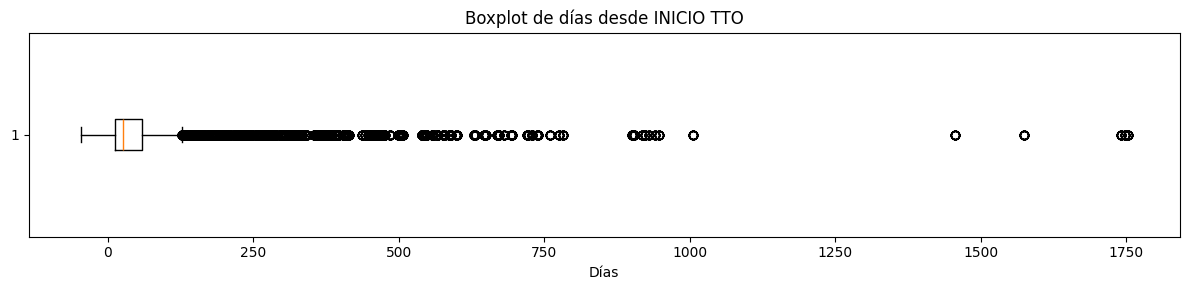

In [ ]:
plt.figure(figsize=(12,3))

plt.boxplot(
    base['dias'],
    vert=False
)

plt.title('Boxplot de días desde INICIO TTO')
plt.xlabel('Días')

plt.tight_layout()
plt.show()

In [ ]:
base = base[ #ME QUEDO CON LAS RESPUESTA EN UN RANGO DE 0 A 180 DIAS
    (base['dias'] >= 0) &
    (base['dias'] <= 180)
]

In [ ]:
# Crear bloques temporales ajustados

base['BLOQUE_DIAS'] = pd.cut(
    base['dias'],
    bins=[0, 30, 60, 90, 180],
    labels=['0-30', '31-60', '61-90', '>90'],
    include_lowest=True
)

# Ver distribución

base['BLOQUE_DIAS'].value_counts(dropna=False)

,count
BLOQUE_DIAS,
0-30,16218
31-60,5649
>90,2095
61-90,1561


In [ ]:
base['Pat_ID'].nunique()

449

### EDAD

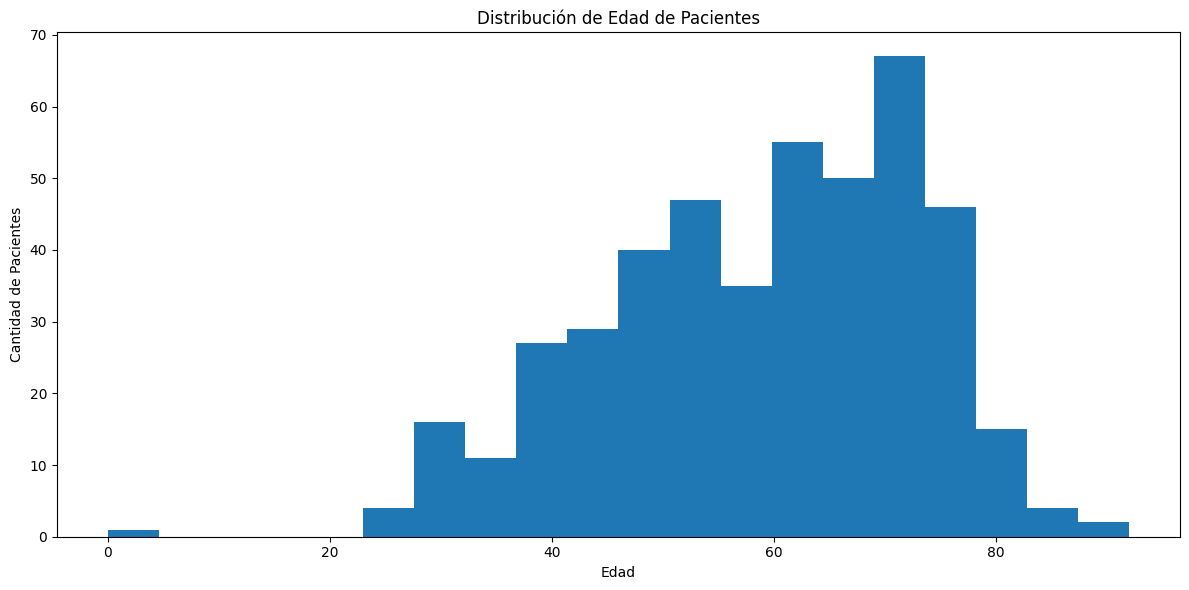

In [ ]:
# Pacientes únicos por edad
df_hist = (
    base[['Pat_ID', 'EDAD']]
    .drop_duplicates(subset='Pat_ID')
)

plt.figure(figsize=(12,6))

plt.hist(df_hist['EDAD'], bins=20)

plt.title('Distribución de Edad de Pacientes')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Pacientes')

plt.tight_layout()
plt.show()

In [ ]:
base= base[base['EDAD']>18] #me quedo con los pacientes mayores

In [ ]:
base['RANGO_ETARIO'] = pd.cut(
    base['EDAD'],
    bins=[0, 39, 49, 59, 69, 79, 120],
    labels=['<40', '40-49', '50-59', '60-69', '70-79', '80+']
) #creo rangos de edad

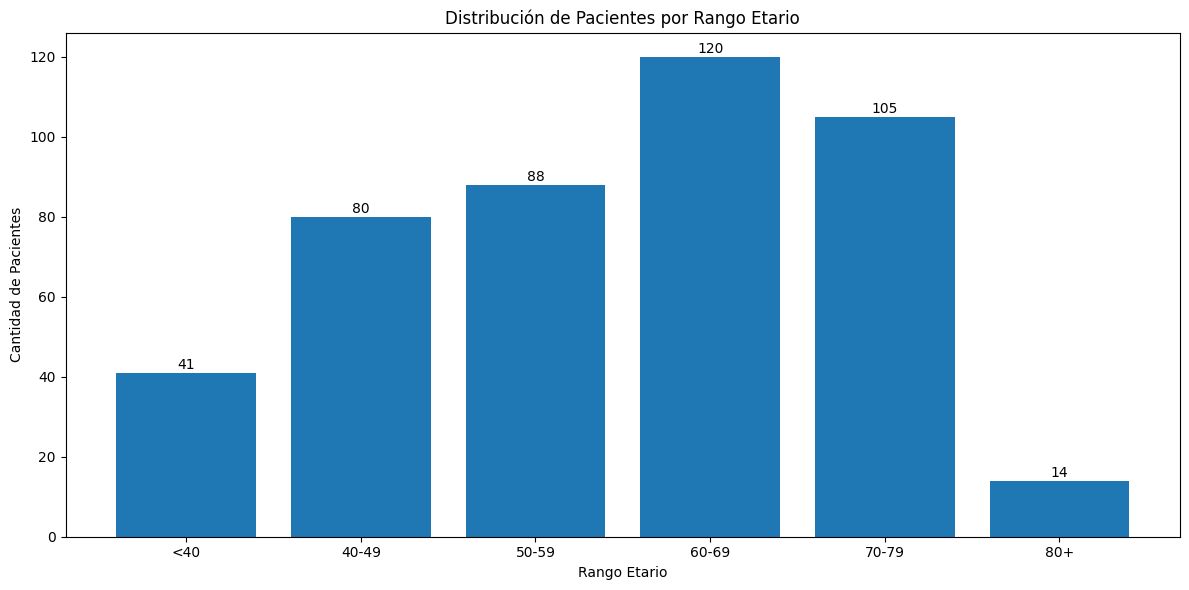

In [ ]:
import matplotlib.pyplot as plt

# Pacientes únicos por rango etario
df_hist = (
    base[['Pat_ID', 'RANGO_ETARIO']]
    .drop_duplicates(subset='Pat_ID')
)

conteo = df_hist['RANGO_ETARIO'].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.bar(conteo.index.astype(str), conteo.values)

plt.title('Distribución de Pacientes por Rango Etario')
plt.xlabel('Rango Etario')
plt.ylabel('Cantidad de Pacientes')

# Etiquetas
for i, v in enumerate(conteo.values):
    plt.text(i, v + 1, str(v), ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# Crear respuesta binaria
base['Respuesta_BIN'] = base['Respuesta'].replace({
    'No': 'No/Leve',
    'Leve': 'No/Leve',
    'Moderado': 'Moderado/Severo',
    'Severo': 'Moderado/Severo'
})

# Tabla porcentual
tabla_edad_bin = pd.crosstab(
    base['RANGO_ETARIO'],
    base['Respuesta_BIN'],
    normalize='index'
) * 100

tabla_edad_bin

Respuesta_BIN,Moderado/Severo,No/Leve
RANGO_ETARIO,,
<40,14.953726,85.046274
40-49,11.849957,88.150043
50-59,12.456747,87.543253
60-69,10.633214,89.366786
70-79,10.629035,89.370965
80+,19.106700,80.893300


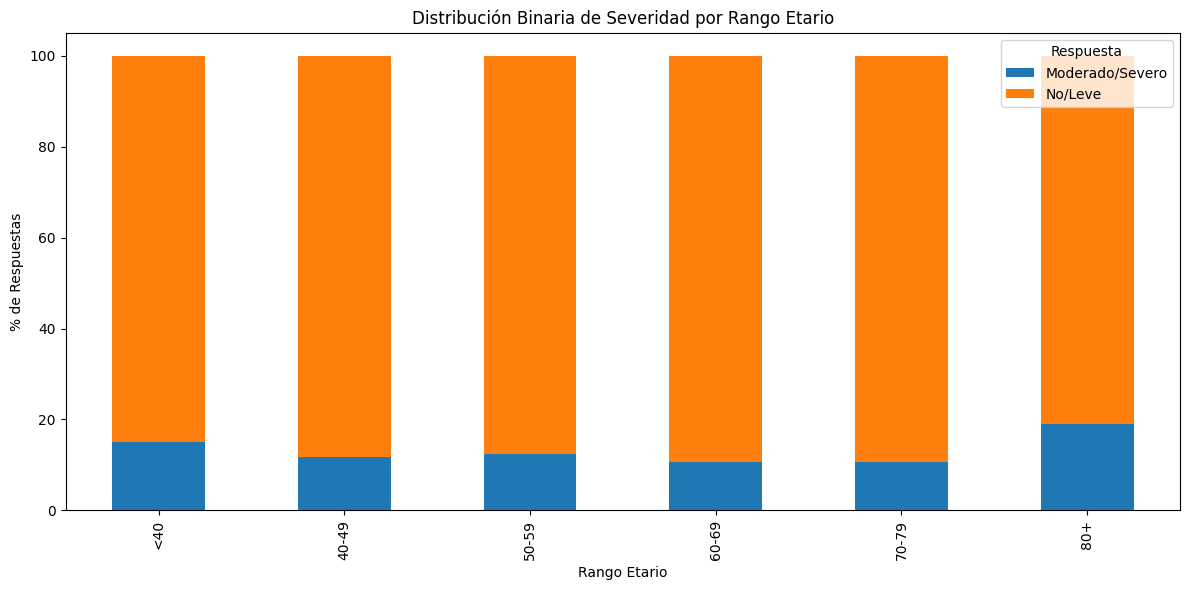

In [ ]:
# Plot
tabla_edad_bin.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Distribución Binaria de Severidad por Rango Etario')
plt.xlabel('Rango Etario')
plt.ylabel('% de Respuestas')

plt.legend(title='Respuesta')

plt.tight_layout()
plt.show()

### REGION

In [ ]:
base['Label'] = (
    base['Label']
    .str.lower()
)

In [ ]:
resp_region = (
    base['CLASIFICACION']
    .value_counts()
    .reset_index()
)

resp_region.columns = [
    'Region_Tratamiento',
    'Cantidad_Respuestas'
]

resp_region

,Region_Tratamiento,Cantidad_Respuestas
0,Pelvis,8660
1,Prostata,6807
2,Mama,5998
3,Cabeza y Cuello,2100
4,Lesiones oseas,843
5,Torax,502
6,OTRO,341
7,Abdomen,167


In [ ]:
base = base[
    base['CLASIFICACION'] != 'OTRO' #sacamos OTRO, dejamos las otras regiones
]

In [ ]:
tabla_region = (
    base.groupby('CLASIFICACION')
    .agg(
        Pacientes=('Pat_ID', 'nunique'),
        Respuestas=('CLASIFICACION', 'size')
    )
    .reset_index()
    .sort_values('Pacientes', ascending=False)
)

tabla_region

,CLASIFICACION,Pacientes,Respuestas
3,Mama,173,5998
4,Pelvis,104,8660
5,Prostata,81,6807
1,Cabeza y Cuello,34,2100
2,Lesiones oseas,23,843
6,Torax,16,502
0,Abdomen,7,167


### SINTOMAS

In [ ]:
base['Label'] = (
    base['Label']
    .str.replace(r'Kaiku\s*:?\s*', '', regex=True)
    .str.replace('*', '', regex=False)
) #Limpiamos los nombres de los sintomas

In [ ]:
base['Label'].nunique()

49

In [ ]:
conteo_sintomas = (
    base['Label']
    .value_counts()
    .reset_index()
)

conteo_sintomas.columns = ['Sintoma', 'Cantidad_Respuestas']

conteo_sintomas

,Sintoma,Cantidad_Respuestas
0,kaiku: dolor,2005
1,kaiku: fatiga,2005
2,kaiku: náuseas,1621
3,kaiku: vómitos,1277
4,kaiku: hinchazón,1112
5,kaiku: disminución apetito,1073
6,kaiku: cambios en piel causad,1041
7,kaiku: diarrea,1029
8,kaiku: sangre en las heces,998
9,kaiku: retención urinaria,998


In [ ]:
# Normalizar texto
base["Label"] = (
    base["Label"]
        .astype(str)
        .str.lower()
        .str.strip()
        .str.replace("kaiku: ", "", regex=False)
)

In [ ]:
# Diccionario de unificación
mapeo_sintomas = {

    # apetito
    'disminución del apetito': 'disminución apetito',

    # piel
    'cambios en piel causad': 'alteraciones cutáneas',
    '+cambios en piel causad': 'alteraciones cutáneas',
    '+alteraciones cutáneas': 'alteraciones cutáneas',

    # urinarios
    'frecuencia urinaria': 'micción frecuente',
    'urgencia urinaria': 'micción frecuente',

    'micción dolorosa': 'dolor al orinar',

    'sangre en orina': 'sangre en la orina',

    # respiratorio
    'dificultad para respira': 'dificultad respiratoria',

    # gusto
    'cambios en el gusto': 'alteraciones en el gusto',
    'alteraciones en el gust': 'alteraciones en el gusto',

    # boca seca
    'boca seca causada por r': 'boca seca',

    # cefalea
    'dolor cabeza': 'dolor de cabeza',

    # cabello
    'pérdida cabello': 'pérdida de cabello',

    # secreción
    'secreción mucosa o con': 'secreción mucosa o sangre',

    # mama
    'cambios en los senos': 'alteraciones en los senos',
    'alteraciones en los sen': 'alteraciones en los senos',
    'sensibilidad en los sen': 'alteraciones en los senos'
}

# Aplicar homologación
base['Label'] = base['Label'].replace(mapeo_sintomas)

In [ ]:
base['Label'].nunique()

34

In [ ]:
# Contar respuestas por síntoma
conteo = base['Label'].value_counts()

# Síntomas con al menos 100 respuestas
sintomas_validos = conteo[conteo >= 100].index

# Filtrar base
base = base[base['Label'].isin(sintomas_validos)].copy()

In [ ]:
base['Label'].nunique()

28

In [ ]:
base['Label'].unique()

array(['alteraciones cutáneas', 'diarrea', 'disminución apetito', 'dolor',
       'dolor al orinar', 'dolor vaginal', 'fatiga',
       'funcionamiento sexual', 'incontinencia urinaria',
       'micción frecuente', 'náuseas', 'retención urinaria',
       'sangrado vaginal', 'sangre en la orina', 'sangre en las heces',
       'sequedad vaginal', 'vómitos', 'dificultad respiratoria',
       'hinchazón', 'tos', 'alteraciones en los senos',
       'disfunción eréctil', 'úlceras bucales',
       'alteraciones en el gusto', 'dificultades para traga', 'ronquera',
       'hinchazón causada por', 'secreción mucosa o sangre'], dtype=object)

me quedan 28 sintomas, los mas relevantes clinicamentes.

### SEXO

In [ ]:
# Cantidad de respuestas por sexo
resp_sexo = (
    base.groupby('SEXO')
    .size()
    .reset_index(name='Cantidad_Respuestas')
)

# Cantidad de pacientes únicos por sexo
pacientes_sexo = (
    base.groupby('SEXO')['Pat_ID']
    .nunique()
    .reset_index(name='Cantidad_Pacientes')
)

# Merge
promedio_sexo = resp_sexo.merge(
    pacientes_sexo,
    on='SEXO'
)

# Promedio
promedio_sexo['Promedio_Respuestas_Paciente'] = (
    promedio_sexo['Cantidad_Respuestas'] /
    promedio_sexo['Cantidad_Pacientes']
)

promedio_sexo

,SEXO,Cantidad_Respuestas,Cantidad_Pacientes,Promedio_Respuestas_Paciente
0,Hombre,11375,156,72.916667
1,Mujer,13424,282,47.602837


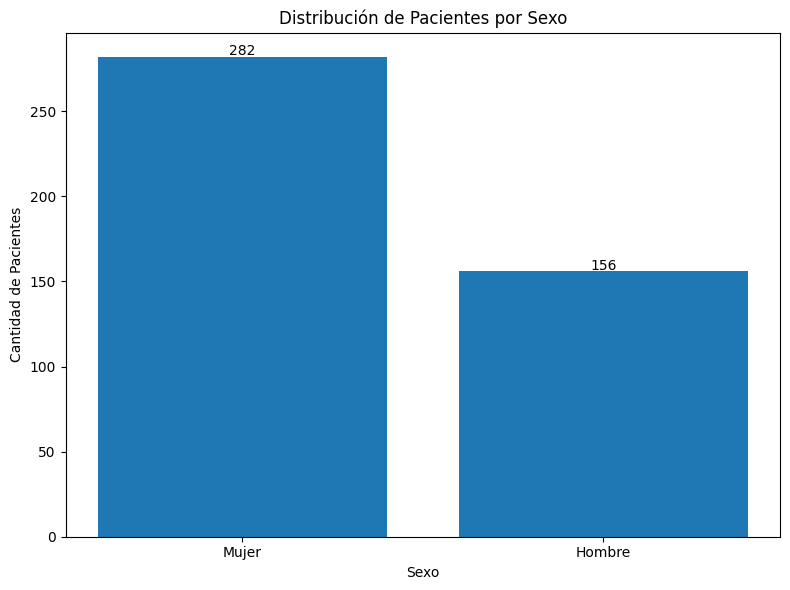

In [ ]:
import matplotlib.pyplot as plt

# Pacientes únicos por sexo
df_sexo = (
    base[['Pat_ID', 'SEXO']]
    .drop_duplicates(subset='Pat_ID')
)

conteo = df_sexo['SEXO'].value_counts()

plt.figure(figsize=(8,6))

plt.bar(conteo.index.astype(str), conteo.values)

plt.title('Distribución de Pacientes por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de Pacientes')

# Etiquetas
for i, v in enumerate(conteo.values):
    plt.text(i, v + 1, str(v), ha='center')

plt.tight_layout()
plt.show()

### TECNICA

In [ ]:
base.loc[
    base["SESIONES"].isna()
].drop_duplicates(subset="Pat_ID")[
    ["Pat_ID", "TECNICA", "SESIONES"]
]

,Pat_ID,TECNICA,SESIONES
1296,47271,RCx,NaN


In [ ]:
base.loc[base["SESIONES"].isna(), "Pat_ID"].unique() #identifico pacientes Nan en sesiones

array([47271])

In [ ]:
base.loc[
    base["Pat_ID"] == 47271
]

,Label,fecha respuesta,RDT.Short_desc,INICIO TTO,dias,Pat_ID,resp,Respuesta,Fec nac,SEXO,Region,CLASIFICACION,SESIONES,TECNICA,EDAD,BLOQUE_DIAS,RANGO_ETARIO,Respuesta_BIN
1296,alteraciones cutáneas,2023-10-15 15:03:43,Inicio RT,2023-10-12 11:30:00,3.148414,47271,0,No,1951-01-24,Mujer,SRS Metastasis cerebral,Cabeza y Cuello,NaN,RCx,72,0-30,70-79,No/Leve
1297,úlceras bucales,2023-10-15 15:03:43,Inicio RT,2023-10-12 11:30:00,3.148414,47271,0,No,1951-01-24,Mujer,SRS Metastasis cerebral,Cabeza y Cuello,NaN,RCx,72,0-30,70-79,No/Leve
1298,alteraciones en el gusto,2023-10-15 15:03:43,Inicio RT,2023-10-12 11:30:00,3.148414,47271,0,No,1951-01-24,Mujer,SRS Metastasis cerebral,Cabeza y Cuello,NaN,RCx,72,0-30,70-79,No/Leve
1299,dificultad respiratoria,2023-10-15 15:03:43,Inicio RT,2023-10-12 11:30:00,3.148414,47271,0,No,1951-01-24,Mujer,SRS Metastasis cerebral,Cabeza y Cuello,NaN,RCx,72,0-30,70-79,No/Leve
1300,dificultades para traga,2023-10-15 15:03:43,Inicio RT,2023-10-12 11:30:00,3.148414,47271,0,No,1951-01-24,Mujer,SRS Metastasis cerebral,Cabeza y Cuello,NaN,RCx,72,0-30,70-79,No/Leve
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3151,fatiga,2023-12-30 09:33:16,Inicio RT,2023-10-12 11:30:00,78.918935,47271,2,Moderado,1951-01-24,Mujer,SRS Metastasis cerebral,Cabeza y Cuello,NaN,RCx,72,61-90,70-79,Moderado/Severo
3152,náuseas,2023-12-30 09:33:16,Inicio RT,2023-10-12 11:30:00,78.918935,47271,0,No,1951-01-24,Mujer,SRS Metastasis cerebral,Cabeza y Cuello,NaN,RCx,72,61-90,70-79,No/Leve
3153,ronquera,2023-12-30 09:33:16,Inicio RT,2023-10-12 11:30:00,78.918935,47271,2,Moderado,1951-01-24,Mujer,SRS Metastasis cerebral,Cabeza y Cuello,NaN,RCx,72,61-90,70-79,Moderado/Severo
3154,tos,2023-12-30 09:33:16,Inicio RT,2023-10-12 11:30:00,78.918935,47271,3,Severo,1951-01-24,Mujer,SRS Metastasis cerebral,Cabeza y Cuello,NaN,RCx,72,61-90,70-79,Moderado/Severo


In [ ]:
# Dataset único por paciente
base_pacientes = (
    base.groupby("Pat_ID", as_index=False)
        .agg({
            "TECNICA": "first",
            "SESIONES": "first"
        })
)

# Media de sesiones para RCx (por paciente)
media_rcx = (
    base_pacientes.loc[
        base_pacientes["TECNICA"] == "RCx",
        "SESIONES"
    ]
    .mean()
)

print(media_rcx)

6.833333333333333


In [ ]:
base.loc[
    (base["TECNICA"] == "RCx") & (base["SESIONES"].isna()),
    "SESIONES"
] = media_rcx #COMPLETO EL PACIENTE CON LA MEDIA DE SESIONES POR TECNICA

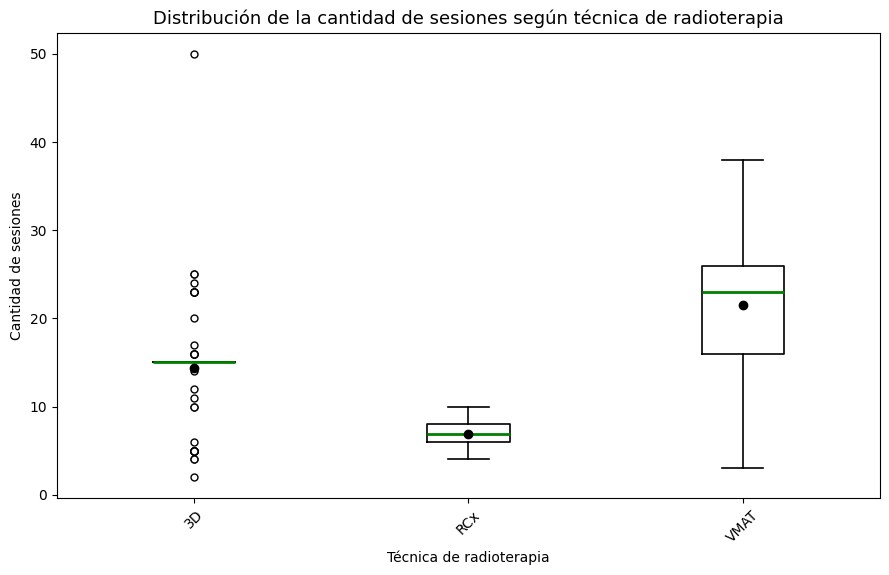

In [ ]:
import matplotlib.pyplot as plt

# ==============================
# Dataset único por paciente
# ==============================

base_pacientes = (
    base.groupby("Pat_ID", as_index=False)
        .agg({
            "TECNICA": "first",
            "SESIONES": "first"
        })
)

# ==============================
# Boxplot
# ==============================

fig, ax = plt.subplots(figsize=(9,6))

base_pacientes.boxplot(
    column="SESIONES",
    by="TECNICA",
    ax=ax,
    grid=False,
    showmeans=True,
    meanprops=dict(
        marker='o',
        markerfacecolor='black',
        markeredgecolor='black',
        markersize=6
    ),
    medianprops=dict(color='green', linewidth=2),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(
        marker='o',
        markerfacecolor='white',
        markeredgecolor='black',
        markersize=5
    )
)

ax.set_title("Distribución de la cantidad de sesiones según técnica de radioterapia", fontsize=13)
plt.suptitle("")
ax.set_xlabel("Técnica de radioterapia")
ax.set_ylabel("Cantidad de sesiones")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## RESULTADOS

### FRECUENCIA DE SINTOMAS

In [ ]:
total_pacientes = base["Pat_ID"].nunique()

pacientes_severos = base.loc[
    base["SEVERO_BIN"] == 1, "Pat_ID"
].nunique()

print(f"Pacientes con al menos un síntoma moderado/severo: {pacientes_severos}")
print(f"Total de pacientes: {total_pacientes}")
print(f"Porcentaje: {pacientes_severos / total_pacientes * 100:.1f}%")

Pacientes con al menos un síntoma moderado/severo: 344
Total de pacientes: 438
Porcentaje: 78.5%


Primer resultado importante, el 78,5% de los pacientes reporto 1 o más síntomas moderado/severo

In [ ]:
tabla_freq = (
    base['Label']
    .value_counts()
    .reset_index()
)

tabla_freq.columns = ['Sintoma', 'Frecuencia']

tabla_freq.head(10)

,Sintoma,Frecuencia
0,dolor,2005
1,fatiga,2005
2,micción frecuente,1996
3,disminución apetito,1816
4,alteraciones cutáneas,1791
5,náuseas,1621
6,vómitos,1277
7,hinchazón,1112
8,diarrea,1029
9,retención urinaria,998


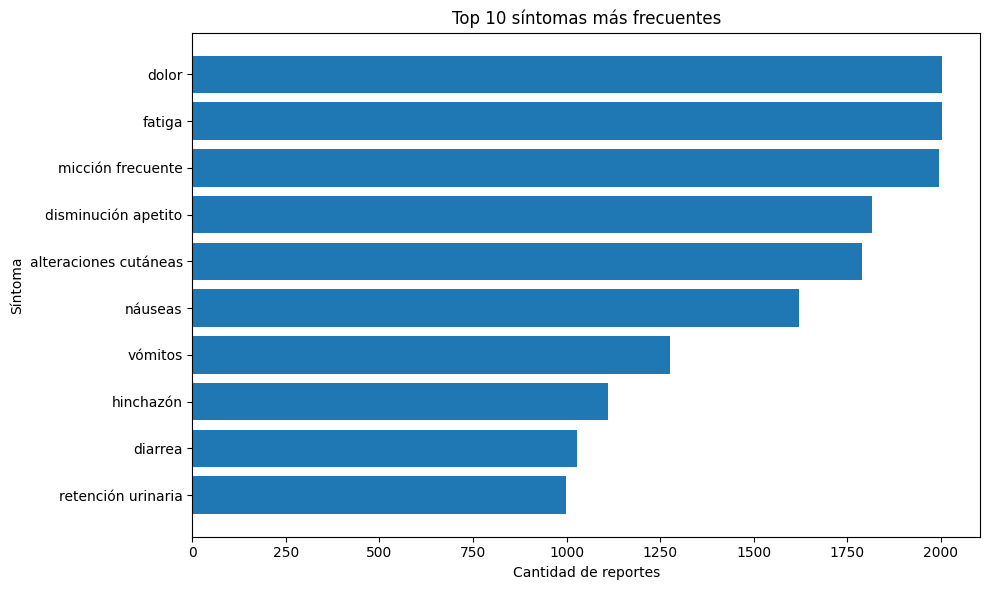

In [ ]:
top10 = tabla_freq.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Sintoma'][::-1],
    top10['Frecuencia'][::-1]
)

plt.title('Top 10 síntomas más frecuentes')
plt.xlabel('Cantidad de reportes')
plt.ylabel('Síntoma')

plt.tight_layout()
plt.show()

In [ ]:
# Crear variable binaria moderado/severo
base['SEVERO_BIN'] = base['Respuesta'].isin([
    'Moderado',
    'Severo'
]).astype(int)

# Tabla resumen por síntoma
tabla_severidad = (
    base
    .groupby('Label')
    .agg(
        total=('SEVERO_BIN', 'count'),
        severos=('SEVERO_BIN', 'sum')
    )
    .reset_index()
)

# Calcular porcentaje
tabla_severidad['porcentaje_severidad'] = (
    tabla_severidad['severos']
    / tabla_severidad['total']
) * 100

# Filtrar síntomas con suficiente volumen
tabla_severidad = tabla_severidad[
    tabla_severidad['total'] >= 100
]

# Ordenar
tabla_severidad = tabla_severidad.sort_values(
    'porcentaje_severidad',
    ascending=False
)

# Top 10
top10_severidad = tabla_severidad.head(25)

top10_severidad

,Label,total,severos,porcentaje_severidad
10,dolor vaginal,281,89,31.672598
1,alteraciones en el gusto,208,53,25.480769
3,diarrea,1029,228,22.157434
19,ronquera,208,45,21.634615
9,dolor al orinar,998,215,21.543086
7,disminución apetito,1816,363,19.988987
8,dolor,2005,371,18.503741
11,fatiga,2005,368,18.354115
27,úlceras bucales,112,19,16.964286
5,dificultades para traga,208,35,16.826923


### HEATMAP

In [ ]:
df_heat = base[
    base['Respuesta_BIN'] == 'Moderado/Severo'
].copy()

In [ ]:
tabla = pd.crosstab(
    df_heat['CLASIFICACION'],
    df_heat['Label'],
    normalize='index'
) * 100

In [ ]:
tabla = tabla[
    tabla.sum()
    .sort_values(ascending=False)
    .index
]

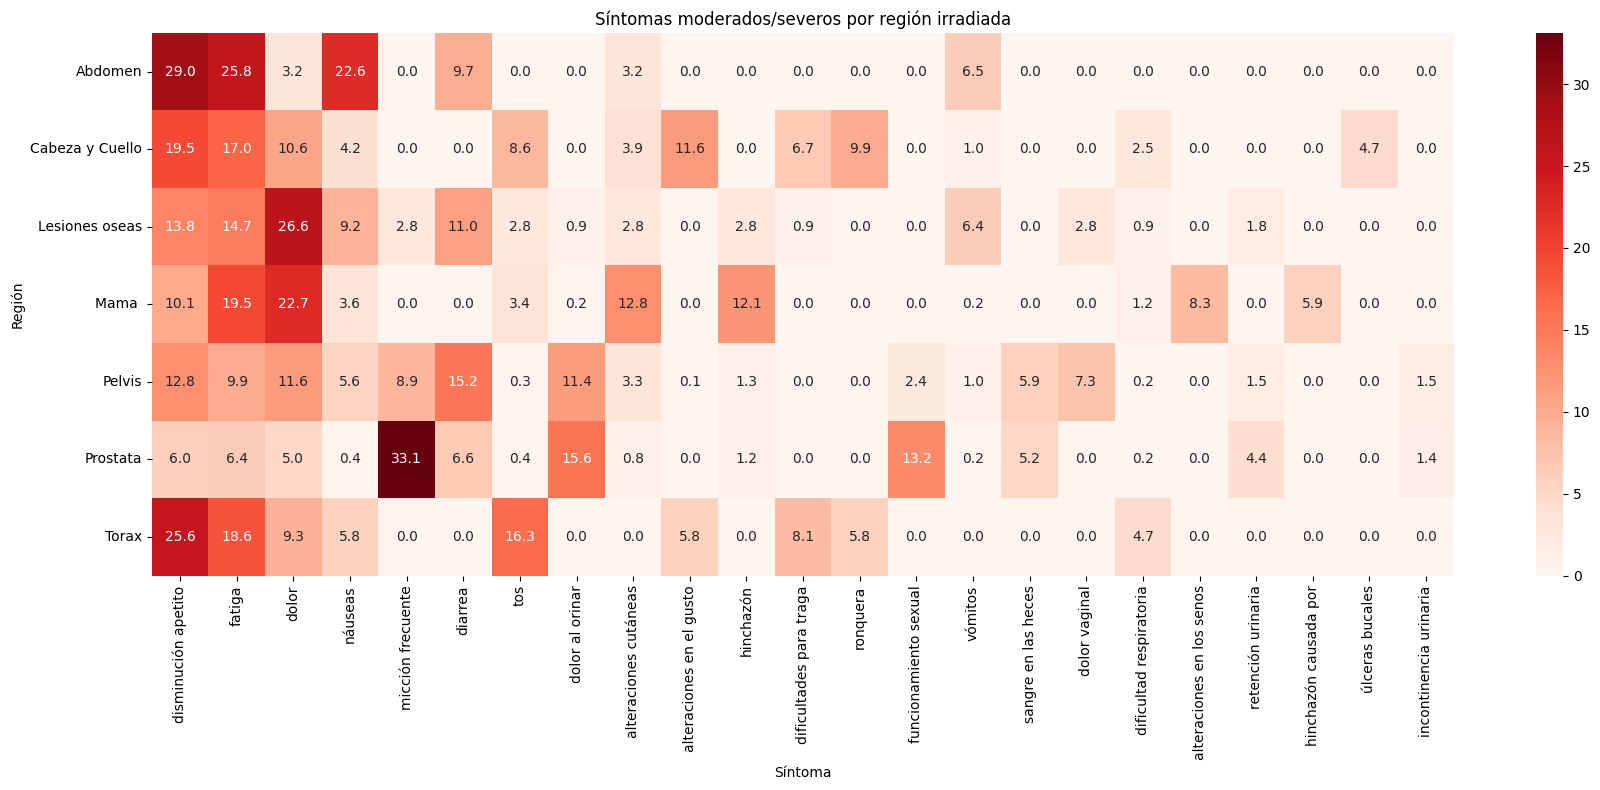

In [ ]:
plt.figure(figsize=(18,8))

sns.heatmap(
    tabla,
    cmap='Reds',
    annot=True,
    fmt='.1f'
)

plt.title('Síntomas moderados/severos por región irradiada')
plt.xlabel('Síntoma')
plt.ylabel('Región')

plt.tight_layout()
plt.show()

Se evidencian patrones de severidad específicos para cada región anatómica, observándose una mayor concentración de determinados síntomas moderados o severos en función del sitio irradiado. Estos resultados refuerzan la importancia de considerar la región tratada al analizar la evolución de los síntomas reportados por los pacientes

### REGRESION LOGISTICA

In [ ]:
# Pacientes únicos
pacientes_unicos = base['Pat_ID'].nunique()

# Cantidad total de respuestas/registros
total_registros = len(base)

# Síntomas únicos
sintomas_unicos = base['Label'].nunique()

# Regiones únicas
regiones_unicas = base['CLASIFICACION'].nunique()

# Distribución variable objetivo
clases = base['SEVERO_BIN'].value_counts()

# Tabla resumen
tabla_resumen = pd.DataFrame({
    'Variable': [
        'Pacientes únicos',
        'Respuestas analizadas',
        'Síntomas únicos',
        'Regiones irradiadas'
    ],
    'Cantidad': [
        pacientes_unicos,
        total_registros,
        sintomas_unicos,
        regiones_unicas
    ]
})

print(tabla_resumen)

print('\nDistribución SEVERO_BIN')
print(clases)

                Variable  Cantidad
0       Pacientes únicos       438
1  Respuestas analizadas     24799
2        Síntomas únicos        28
3    Regiones irradiadas         7

Distribución SEVERO_BIN
SEVERO_BIN
0    21920
1     2879
Name: count, dtype: int64


In [ ]:
base["SEVERO_BIN"].value_counts() #Acá podemos ver el desbalance de la variables objetivo

,count
SEVERO_BIN,
0,21920
1,2879


#### MODELO BASE SIN CORRECCIÓN DEL DESBALANCE DE CLASE

In [ ]:
# =====================================
# REGRESIÓN LOGÍSTICA
# MODELO BASE SIN CORRECCIÓN DEL DESBALANCE
# =====================================

# Variable objetivo
y = base["SEVERO_BIN"]

# =====================================
# VARIABLES PREDICTORAS
# =====================================

X = pd.get_dummies(
    base[
        [
            "CLASIFICACION",
            "SEXO",
            "RANGO_ETARIO",
            "Label",
            "BLOQUE_DIAS"
        ]
    ],
    drop_first=True
)

# =====================================
# DIVISIÓN DEL CONJUNTO DE DATOS
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

# =====================================
# ENTRENAMIENTO DEL MODELO
# =====================================

modelo_base = LogisticRegression(
    max_iter=MAX_ITER,
    random_state=RANDOM_STATE
)

modelo_base.fit(X_train, y_train)

# =====================================
# PREDICCIÓN
# =====================================

y_pred_base = modelo_base.predict(X_test)

# =====================================
# EVALUACIÓN DEL MODELO
# =====================================

print(classification_report(y_test, y_pred_base))

# =====================================
# IMPORTANCIA DE VARIABLES
# =====================================

coeficientes_base = (
    pd.DataFrame({
        "Variable": X.columns,
        "Coeficiente": modelo_base.coef_[0]
    })
    .sort_values(by="Coeficiente", ascending=False)
    .reset_index(drop=True)
)

coeficientes_base

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      6595
           1       0.00      0.00      0.00       845

    accuracy                           0.89      7440
   macro avg       0.44      0.50      0.47      7440
weighted avg       0.79      0.89      0.83      7440



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Variable,Coeficiente
0,Label_dolor vaginal,1.444563
1,Label_diarrea,1.391108
2,Label_dolor al orinar,1.341278
3,Label_disminución apetito,1.212630
4,Label_dolor,1.172266
5,Label_fatiga,1.120317
6,Label_alteraciones en el gusto,0.950080
7,Label_funcionamiento sexual,0.902194
8,Label_micción frecuente,0.840649
9,Label_hinchazón causada por,0.682623


El modelo base, entrenado sin corrección del desbalance de clases, alcanzó una exactitud del 89%. Sin embargo, este desempeño estuvo fuertemente influenciado por la clase mayoritaria, ya que clasificó correctamente casi todas las observaciones sin síntomas moderados/severos (recall = 1,00), pero no logró identificar ninguna observación correspondiente a la clase minoritaria (recall = 0,00). Estos resultados evidencian el impacto del desbalance de clases y justifican la incorporación de la corrección mediante class_weight='balanced' en el modelo final.

#### MODELO BASE CON CORRECCIÓN DEL DESBALANCE DE CLASES (class_weight='balanced')

Se entrenó un modelo de regresión logística utilizando variables demográficas, clínicas y temporales. Debido al desbalance de la variable objetivo, se aplicó una corrección mediante el parámetro class_weight='balanced', con el fin de mejorar la capacidad del modelo para identificar las observaciones correspondientes a la clase minoritaria.

In [ ]:
# =====================================
# REGRESIÓN LOGÍSTICA
# =====================================

# Variable objetivo
y = base["SEVERO_BIN"]

# =====================================
# VARIABLES PREDICTORAS
# =====================================

X = pd.get_dummies(
    base[
        [
            "CLASIFICACION",
            "SEXO",
            "RANGO_ETARIO",
            "Label",
            "BLOQUE_DIAS"
        ]
    ],
    drop_first=True
)

# =====================================
# DIVISIÓN DEL CONJUNTO DE DATOS
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

# =====================================
# ENTRENAMIENTO DEL MODELO
# =====================================

modelo = LogisticRegression(
    class_weight="balanced",
    max_iter=MAX_ITER,
    random_state=RANDOM_STATE
)

modelo.fit(X_train, y_train)

# =====================================
# PREDICCIÓN
# =====================================

y_pred = modelo.predict(X_test)

# =====================================
# EVALUACIÓN DEL MODELO
# =====================================

print(classification_report(y_test, y_pred))

# =====================================
# IMPORTANCIA DE VARIABLES
# =====================================

coeficientes = (
    pd.DataFrame({
        "Variable": X.columns,
        "Coeficiente": modelo.coef_[0]
    })
    .sort_values(by="Coeficiente", ascending=False)
    .reset_index(drop=True)
)

coeficientes

              precision    recall  f1-score   support

           0       0.95      0.57      0.72      6595
           1       0.19      0.76      0.30       845

    accuracy                           0.60      7440
   macro avg       0.57      0.67      0.51      7440
weighted avg       0.86      0.60      0.67      7440



,Variable,Coeficiente
0,Label_dolor vaginal,1.392155
1,Label_diarrea,1.339022
2,Label_dolor al orinar,1.334122
3,Label_dolor,1.116679
4,Label_disminución apetito,1.102862
5,Label_fatiga,1.057712
6,Label_funcionamiento sexual,0.973505
7,Label_micción frecuente,0.941282
8,Label_alteraciones en el gusto,0.822782
9,Label_hinchazón causada por,0.634622


#### MODELO ENRIQUECIDO

Se incorporaron variables relacionadas con el tratamiento (técnica y cantidad de sesiones) con el objetivo de evaluar si mejoraban el desempeño predictivo respecto del modelo base.

In [ ]:
# =====================================
# REGRESIÓN LOGÍSTICA - MODELO ENRIQUECIDO
# =====================================

# Variable objetivo
y = base["SEVERO_BIN"]

# =====================================
# VARIABLES PREDICTORAS
# =====================================

# Variables categóricas
X_cat = pd.get_dummies(
    base[
        [
            "CLASIFICACION",
            "SEXO",
            "RANGO_ETARIO",
            "Label",
            "BLOQUE_DIAS",
            "TECNICA"
        ]
    ],
    drop_first=True
)

# Variables numéricas
X_num = base[["SESIONES"]]

# Matriz de variables predictoras
X = pd.concat([X_cat, X_num], axis=1)

# =====================================
# DIVISIÓN DEL CONJUNTO DE DATOS
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

# =====================================
# ENTRENAMIENTO DEL MODELO
# =====================================

modelo_enriquecido = LogisticRegression(
    class_weight="balanced",
    max_iter=MAX_ITER,
    random_state=RANDOM_STATE
)

modelo_enriquecido.fit(X_train, y_train)

# =====================================
# PREDICCIÓN Y EVALUACIÓN
# =====================================

y_pred_enriquecido = modelo_enriquecido.predict(X_test)

print(classification_report(y_test, y_pred_enriquecido))

# =====================================
# COEFICIENTES DEL MODELO
# =====================================

coeficientes_enriquecido = (
    pd.DataFrame({
        "Variable": X.columns,
        "Coeficiente": modelo_enriquecido.coef_[0]
    })
    .sort_values("Coeficiente", ascending=False)
    .reset_index(drop=True)
)

coeficientes_enriquecido

              precision    recall  f1-score   support

           0       0.95      0.58      0.72      6595
           1       0.19      0.75      0.30       845

    accuracy                           0.60      7440
   macro avg       0.57      0.67      0.51      7440
weighted avg       0.86      0.60      0.67      7440



,Variable,Coeficiente
0,Label_dolor vaginal,1.381843
1,Label_diarrea,1.338232
2,Label_dolor al orinar,1.335235
3,Label_dolor,1.116845
4,Label_disminución apetito,1.104752
5,Label_fatiga,1.064847
6,Label_funcionamiento sexual,0.970191
7,Label_micción frecuente,0.931824
8,Label_alteraciones en el gusto,0.815778
9,Label_hinchazón causada por,0.620158


#### COMPARACION DE MODELOS Y TRATAMIENTO DEL DESBALANCE DE CLASES

| Modelo                                                              | Accuracy | Precision (Clase 1) | Recall (Clase 1) | F1-score (Clase 1) |
| :------------------------------------------------------------------ | -------: | ------------------: | ---------------: | -----------------: |
| Modelo base (sin corrección del desbalance)                         | **0,89** |            **0,00** |         **0,00** |           **0,00** |
| Modelo base (`class_weight='balanced'`)                             | **0,60** |            **0,19** |         **0,76** |           **0,30** |
| Modelo enriquecido (`class_weight='balanced'` + sesiones y técnica) | **0,60** |            **0,19** |         **0,75** |           **0,30** |


La variable objetivo presentó un marcado desbalance entre las observaciones correspondientes a síntomas leves y aquellas asociadas a síntomas moderados o severos. En este contexto, la exactitud (accuracy) por sí sola no constituye una métrica adecuada para evaluar el desempeño del modelo, ya que puede verse fuertemente influenciada por la clase mayoritaria. Esto se evidenció en el modelo base sin corrección del desbalance, que alcanzó una exactitud del 89%, pero fue incapaz de identificar observaciones de la clase positiva (recall = 0,00), clasificando prácticamente todos los casos como pertenecientes a la clase mayoritaria.

Por este motivo, la evaluación del desempeño se centró principalmente en el recall de la clase positiva, métrica que representa la proporción de pacientes con síntomas moderados o severos correctamente identificados. En el contexto clínico de este trabajo, resulta más relevante maximizar la detección de estos pacientes que obtener una elevada exactitud global, ya que los falsos negativos implican no identificar individuos con mayor carga sintomática.

La incorporación del ajuste de pesos mediante class_weight='balanced' permitió incrementar el recall de la clase positiva hasta 0,76, mejorando sustancialmente la capacidad del modelo para detectar los casos de interés, aunque con la esperable disminución de la exactitud global.

Finalmente, sobre esta configuración se evaluó un modelo enriquecido incorporando la cantidad de sesiones y la técnica de radioterapia. El desempeño obtenido fue prácticamente equivalente al del modelo base balanceado (recall de 0,75 frente a 0,76), sin mejoras relevantes en el resto de las métricas. Estos resultados indican que la incorporación de estas variables aporta escasa información adicional para la predicción de la severidad, sugiriendo que la mayor parte de la capacidad predictiva del modelo ya se encuentra explicada por las variables clínicas originales, como el tipo de síntoma, la región anatómica irradiada y el momento del tratamiento.


### BLOQUE DIAS

A partir del análisis de la importancia de las variables en el modelo de regresión logística, se observó que el **tiempo transcurrido desde el inicio del tratamiento** constituye uno de los factores con mayor capacidad explicativa de la severidad de los síntomas. En función de este hallazgo, se profundizó el análisis temporal con el objetivo de identificar los períodos en los que se concentra la mayor proporción de síntomas moderados o severos y caracterizar su evolución a lo largo del tratamiento.


In [ ]:
base['BLOQUE_DIAS_10'] = pd.cut(
    base['dias'],
    bins=[0,10,20,30,40,50,60,70,80,90],
    labels=[
        '0-10',
        '11-20',
        '21-30',
        '31-40',
        '41-50',
        '51-60',
        '61-70',
        '71-80',
        '81-90'
    ],
    include_lowest=True
)

/tmp/ipykernel_3823/2930044678.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['CLASIFICACION','BLOQUE_DIAS_10'])['SEVERO_BIN']


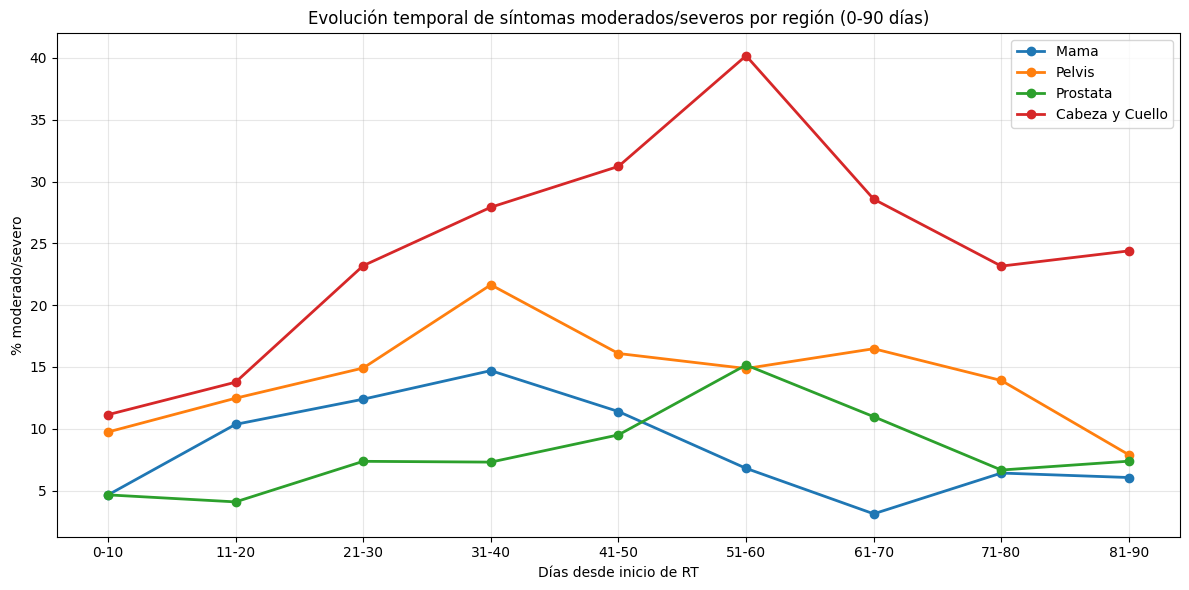

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

regiones = [
    'Mama ',
    'Pelvis',
    'Prostata',
    'Cabeza y Cuello'
]

orden = [
    '0-10',
    '11-20',
    '21-30',
    '31-40',
    '41-50',
    '51-60',
    '61-70',
    '71-80',
    '81-90'
]

tabla = (
    base[
        (base['CLASIFICACION'].isin(regiones))
        &
        (base['BLOQUE_DIAS_10'].isin(orden))
    ]
    .groupby(['CLASIFICACION','BLOQUE_DIAS_10'])['SEVERO_BIN']
    .mean()
    .reset_index()
)

tabla['PORC_SEVERIDAD'] = tabla['SEVERO_BIN'] * 100

tabla['BLOQUE_DIAS_10'] = pd.Categorical(
    tabla['BLOQUE_DIAS_10'],
    categories=orden,
    ordered=True
)

plt.figure(figsize=(12,6))

for region in regiones:

    datos = (
        tabla[
            tabla['CLASIFICACION'] == region
        ]
        .sort_values('BLOQUE_DIAS_10')
    )

    plt.plot(
        datos['BLOQUE_DIAS_10'],
        datos['PORC_SEVERIDAD'],
        marker='o',
        linewidth=2,
        label=region
    )

plt.title('Evolución temporal de síntomas moderados/severos por región (0-90 días)')
plt.xlabel('Días desde inicio de RT')
plt.ylabel('% moderado/severo')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

El análisis temporal evidenció patrones diferenciales de severidad según la región anatómica irradiada. Los pacientes tratados en **Cabeza y Cuello** presentaron la mayor proporción de síntomas moderados o severos, con un incremento progresivo que alcanzó un pico cercano al **40% entre los 51 y 60 días** desde el inicio del tratamiento. La región de **Pelvis** mostró una tendencia similar, aunque de menor magnitud, mientras que **Mama** y **Próstata** mantuvieron porcentajes inferiores y una evolución relativamente estable a lo largo del seguimiento. En conjunto, estos hallazgos indican que el período comprendido entre los **30 y 60 días** concentra la mayor carga sintomática del tratamiento, constituyéndose como una ventana temporal de especial interés para el seguimiento y la implementación de intervenciones clínicas orientadas al manejo oportuno de los síntomas.


## CONCLUSIONES FINALES

a) El 78,5% de los pacientes presentó al menos un síntoma
moderado o severo.

b) La severidad estuvo principalmente asociada al tipo de síntoma, la región anatómica irradiada y el tiempo desde el inicio del tratamiento.

c) El período entre los 30 y 60 días concentró la mayor carga sintomática.

d) El tratamiento del desbalance mediante class_weight='balanced' permitió mejorar la detección de la clase minoritaria, priorizando el Recall.

e) La incorporación de variables relacionadas con la técnica de radioterapia y la cantidad de sesiones no mejoró el desempeño del modelo, lo que sugiere que la información relevante ya estaba capturada por las variables clínicas consideradas.